# Analzye collected data

Here, we gather the data collected from the different models and compare them to human data.

### Import

In [153]:
import pandas as pd
import plotly.express as px
from pathlib import Path
import  matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix,ConfusionMatrixDisplay
import numpy as np
import seaborn as sns

## Parameters

In [2]:
MODELS = [
    "gpt-5.4-nano-2026-03-17",
    "gpt-5.4-mini-2026-03-17",
    "gpt-5.4",
]

### Functions

In [137]:
def read_scores_from_model(model):

    model_name = model + "_"
    files = list(Path("results").glob(f"{model_name}*.csv"))

    df = pd.DataFrame([])

    print(f"Gathered data for model {model} from {len(files)} files.")
    for f in files:
        df_data = pd.read_csv(f'results/{f.name}')
        df_data["run"] = f.name[-5:-4]
        df = pd.concat([df, df_data], ignore_index=True)

    df["model"] = model
    df["id"] = df["id"].astype(int)

    return df


def summarize_scores_from_model(df, model):
    summary = df.groupby("id").agg({"score": ["mean", "std", "sem"]}).reset_index()
    summary.columns = summary.columns.get_level_values(1)
    #summary.columns = ['id', f'{model}_mean', f'{model}_std', f'{model}_sem']
    summary.columns = ['id', 'score_mean', 'score_std', 'score_sem']
    print(f"Summarized data for model {model}.")

    return summary


def collate_human_and_llm_data_wide(MODELS: list) -> pd.DataFrame:
    
    # fetch human data
    df = pd.read_csv("data/iCO-Eval2_summarizedRatings.csv", sep=";")

    # fetch, aggregate and merge LLm data
    for model in MODELS:
        df_model = read_scores_from_model(model)
        summary_model = summarize_scores_from_model(df_model, model)
        summary_model.columns = ['id', f'{model}_mean', f'{model}_std', f'{model}_sem']
        df = pd.merge(df, summary_model, left_on="CODE", right_on="id", how="left").drop(columns='id')
        
    return df


def collate_human_and_llm_data_long(MODELS: list) -> pd.DataFrame:
    
    # fetch human data
    df = pd.read_csv("data/iCO-Eval2_summarizedRatings.csv", sep=";")
    df.drop(columns=["CONTEXT QUESTION", "CRITICAL UTTERANCE", "CORRECT RESPONSE (0=no; 1=yes)", "FUN_std", "FUN_sem", "COH_std", "COH_sem", "DIR_std", "DIR_sem", "PRE_std", "PRE_sem", "SSI_std", "SSI_sem", "CER_std", "CER_sem"], inplace=True) #this is not really necessary

    # add information such as condition and set
    ref = df

    # put them on the same scale as the LLm scores (0-1)
    #df["FUN_mean"] = rescale(df["FUN_mean"], 1, 7)
    #df["COH_mean"] = rescale(df["COH_mean"], 1, 7)
    #df["DIR_mean"] = rescale(df["DIR_mean"], 1, 7)
    #df["PRE_mean"] = rescale(df["PRE_mean"], 1, 7)
    #df["SSI_mean"] = rescale(df["SSI_mean"], 1, 7)
    #df["CER_mean"] = rescale(df["CER_mean"], 1, 4)
    df["evaluator"] = "human"

    # fetch, aggregate and merge LLm data
    for model in MODELS:
        df_model = read_scores_from_model(model)
        summary_model = summarize_scores_from_model(df_model, model)
        
        # only take mean, leave sd and std out
        summary_model  = summary_model[["id", "score_mean"]] 
        summary_model.rename(columns={"score_mean": "FUN_mean", "id": "CODE"}, inplace=True)
        
        # generate certainty score
        summary_model["CER_mean"] = ((summary_model["FUN_mean"] - 4).abs())+1
        
        # add evaluator column to indicate which model the scores are from
        summary_model["evaluator"] = model

        # add SET and CONDITION infformation from the reference human data
        summary_model = summary_model.merge(ref[["CODE", "SET (1=SA-matched;2=non-SA-matched)", "CONDITION"]], on="CODE", how="left", validate="m:1")

        # concatenate with data so far
        df = pd.concat([df, summary_model], axis=0, join='outer').reset_index(drop=True)
        
    # rename SET column
    df = df.rename(columns={"SET (1=SA-matched;2=non-SA-matched)": "SET"})

    return df


def compare_to_human(df_long: pd.DataFrame) -> pd.DataFrame:
    '''Classify scores into 3 classes (score < 4: no, score == 4, unsure, score > 4: yes) for all evaluators and compare moel responses to human ones.'''

    # create a reference data frame containing categorized human scores
    ref = df_long.loc[df_long["evaluator"] == "human", ["CODE", "FUN_mean"]]
    ref.loc[ref["FUN_mean"] < 4, 'reference'] = "no"
    ref.loc[ref["FUN_mean"] > 4, 'reference'] = "yes"
    ref.loc[ref["FUN_mean"] == 4, 'reference'] = "unsure"
    ref

    # marge it to main df_long
    df_long = df_long.merge(ref[["CODE", "reference"]], on="CODE", how="left", validate="m:1")

    # categorize ahuman and model scores
    df_long.loc[df_long["FUN_mean"] < 4, 'response'] = "no"
    df_long.loc[df_long["FUN_mean"] > 4, 'response'] = "yes"
    df_long.loc[df_long["FUN_mean"] == 4, 'response'] = "unsure"

    # compare model nad human to generate accuracy
    df_long['accuracy'] = df_long['response'] == df_long['reference']

    return df_long


def conf_matrix(df_long: pd.DataFrame, MODELS: list):
    '''For each model, creates a confusion matrix (based on 3 classes: yes / unsure / no) and plots it.'''

    for model in MODELS:

        # extract data
        y_true = df_long.loc[df_long['evaluator'] == model, 'reference']
        y_pred_cat = df_long.loc[df_long['evaluator'] == model, 'response']

        # confusion matrix
        cm = confusion_matrix(
            y_true,
            y_pred_cat,
            normalize='all',
            )
        print(type(cm))
        np.savetxt(f"analysis/confusion_matrix_{model}.txt", cm)

        ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred_cat,
        display_labels=["no", "unsure", "yes"],
        cmap='Blues',
        normalize='all',
        )
        plt.title(f"{model}")
        plt.savefig(f"analysis/confusion_matrix_figure_{model}.png")


def roc(df_long: pd.DataFrame, MODELS: list):
    '''Generates and saves ROC curve and AUC values for the models.'''

    for model in MODELS:

        # extract data
        y_true = df_long.loc[df_long['evaluator'] == model, 'reference']
        y_pred_cont = (df_long.loc[df_long['evaluator'] == model, 'FUN_mean'] -1 ) / 7

        # roc curve
        fpr, tpr, _ = roc_curve(y_true, y_pred_cont, pos_label = 'yes')
        roc_auc = auc(fpr, tpr)
        print(type(roc_auc))
        with open(f"analysis/roc_auc_{model}.txt", "w") as f:
            f.write(f"{roc_auc:.4f}")
        
        # plot
        plt.plot(fpr, tpr, label=f"{model} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curve")
    plt.legend()
    plt.savefig(f"analysis/roc_curve.png")

    return

def rescale(series: pd.Series, min: int, max: int) -> pd.Series:
    return (series - min) / (max - min)

### Aggregation

In [13]:
df_wide =  collate_human_and_llm_data_wide(MODELS)
df_long = collate_human_and_llm_data_long(MODELS)
df_long = compare_to_human(df_long)


Gathered data for model gpt-5.4-nano-2026-03-17 from 28 files.
Summarized data for model gpt-5.4-nano-2026-03-17.
Gathered data for model gpt-5.4-mini-2026-03-17 from 28 files.
Summarized data for model gpt-5.4-mini-2026-03-17.
Gathered data for model gpt-5.4 from 28 files.
Summarized data for model gpt-5.4.
Gathered data for model gpt-5.4-nano-2026-03-17 from 28 files.
Summarized data for model gpt-5.4-nano-2026-03-17.
Gathered data for model gpt-5.4-mini-2026-03-17 from 28 files.
Summarized data for model gpt-5.4-mini-2026-03-17.
Gathered data for model gpt-5.4 from 28 files.
Summarized data for model gpt-5.4.


### Visualization

#### Certainty

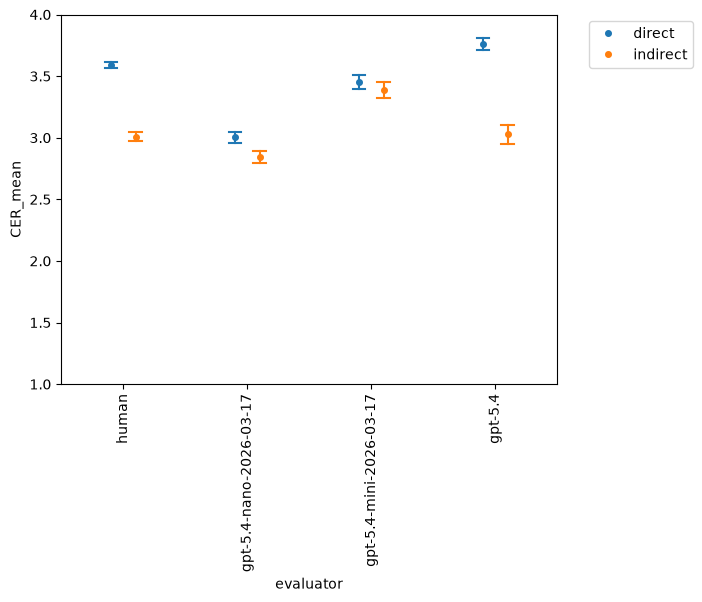

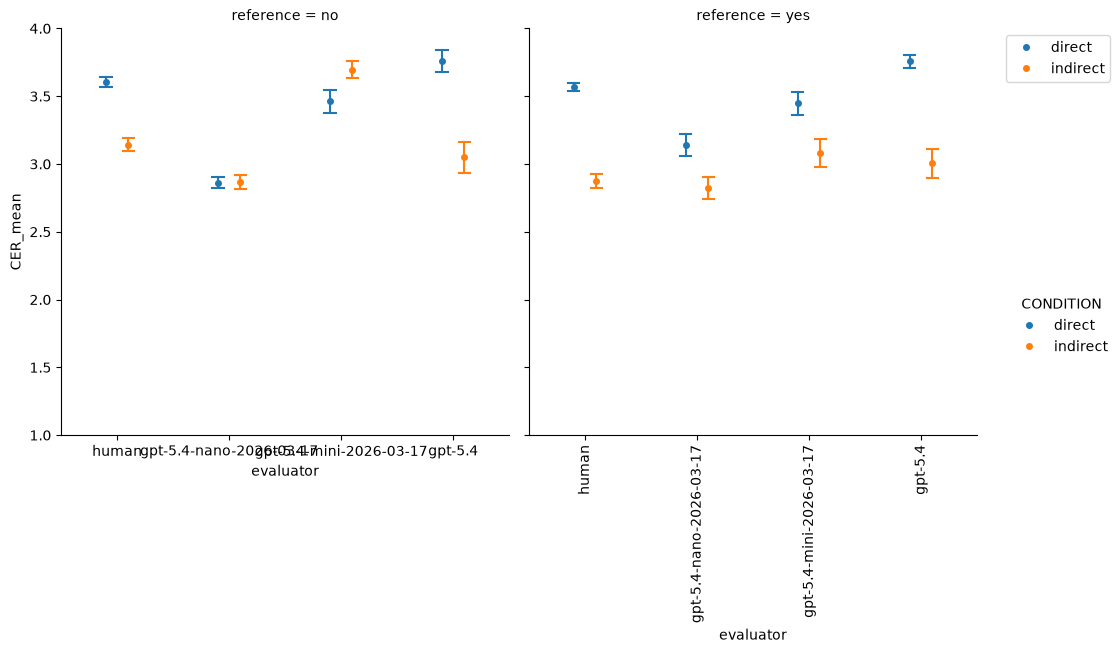

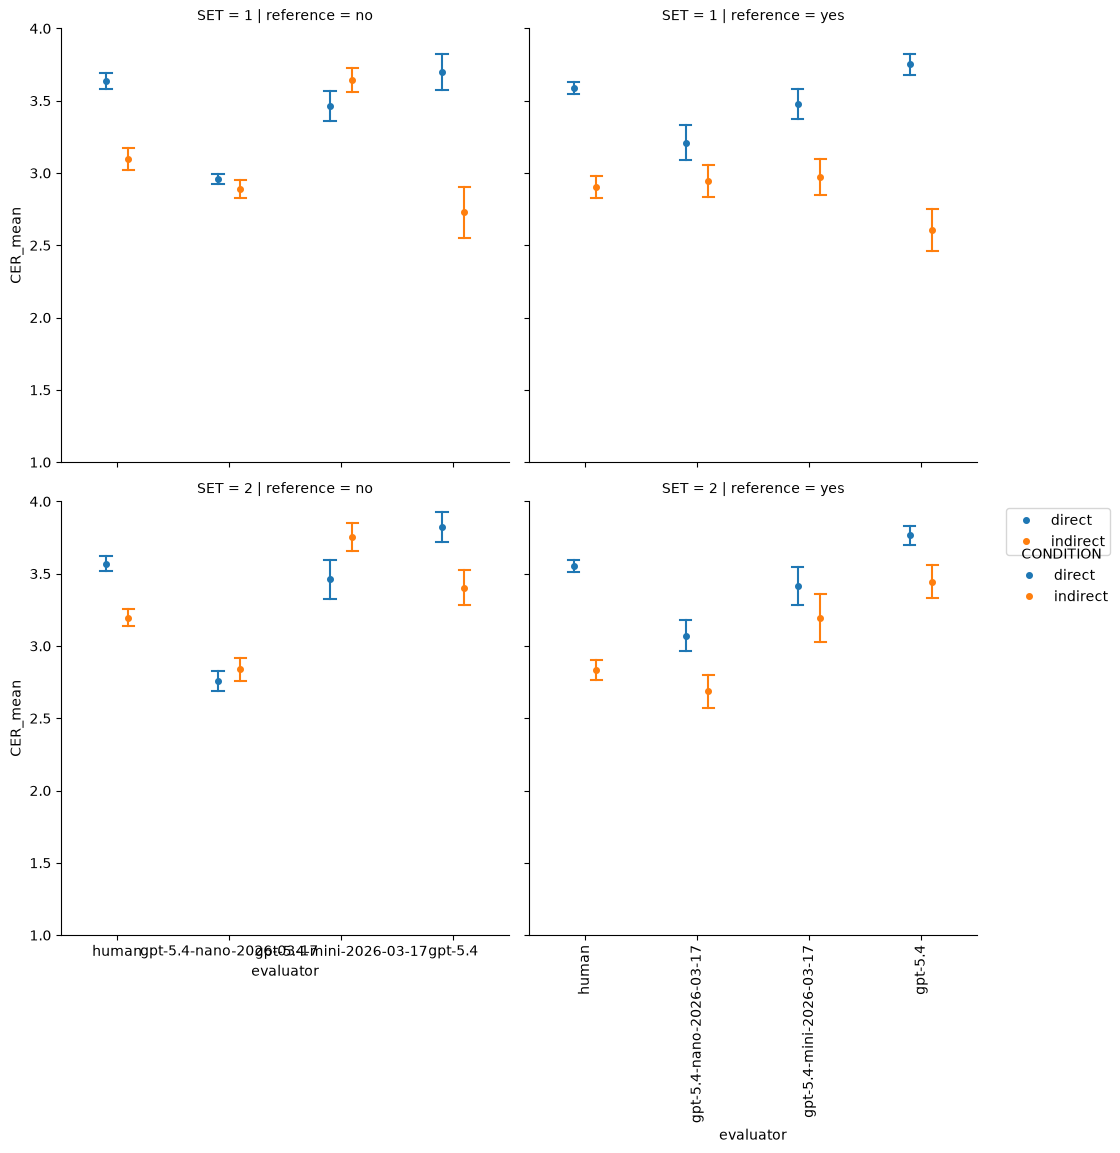

In [ ]:
###

aggregated = df_long.groupby(["evaluator", "CONDITION"]).agg(
    CER_mean=("CER_mean", "mean"),
    CER_sd=("CER_mean", "std"),
    CER_sem=("CER_mean", "sem"),
).reset_index()
aggregated.to_csv("analysis/certainty_summarized_EVAL_X_CONDITION.csv", index=False)

sns.pointplot(
    data=df_long,
    x="evaluator",
    y="CER_mean",
    hue="CONDITION",
    markersize=3,
    dodge=0.2,
    errorbar='se',
    linestyle="none",
    capsize=0.1,
    err_kws={"linewidth": 1.5}
)
plt.ylim([1, 4])
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

###

aggregated = df_long.groupby(["evaluator", "CONDITION", "reference"]).agg(
    CER_mean=("CER_mean", "mean"),
    CER_sd=("CER_mean", "std"),
    CER_sem=("CER_mean", "sem"),
).reset_index()
aggregated.to_csv("analysis/certainty_summarized_EVAL_X_CONDITION_X_REF.csv", index=False)

sns.catplot(
    data=df_long,
    x="evaluator",
    y="CER_mean",
    hue="CONDITION",
    col="reference",
    kind="point",
    markersize=3,
    dodge=0.2,
    errorbar="se",
    linestyle="none",
    capsize=0.1,
    err_kws={"linewidth": 1.5},
)
plt.ylim([1, 4])
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

###

aggregated = df_long.groupby(["evaluator", "CONDITION", "SET", "reference"]).agg(
    CER_mean=("CER_mean", "mean"),
    CER_sd=("CER_mean", "std"),
    CER_sem=("CER_mean", "sem"),
).reset_index()
aggregated.to_csv("analysis/certainty_summarized_EVAL_X_CONDITION_X_SET_REF.csv", index=False)


sns.catplot(
    data=df_long,
    x="evaluator",
    y="CER_mean",
    hue="CONDITION",
    col="reference", 
    row="SET",
    kind="point",
    markersize=3,
    dodge=0.2,
    errorbar="se",
    linestyle="none",
    capsize=0.1,
    err_kws={"linewidth": 1.5},
)
plt.ylim([1, 4])
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


#### Accuracy

In [100]:
aggregated = df_long.groupby(["evaluator", "CONDITION"]).agg(
    accuracy_mean=("accuracy", "mean"),
    accuracy_sd=("accuracy", "std"),
    accuracy_sem=("accuracy", "sem"),
).reset_index()
aggregated

,evaluator,CONDITION,accuracy_mean,accuracy_sd,accuracy_sem
0,gpt-5.4,direct,0.978261,0.146362,0.012459
1,gpt-5.4,indirect,0.956522,0.204674,0.017423
2,gpt-5.4-mini-2026-03-17,direct,0.942029,0.234540,0.019965
3,gpt-5.4-mini-2026-03-17,indirect,0.905797,0.293175,0.024957
4,gpt-5.4-nano-2026-03-17,direct,0.905797,0.293175,0.024957
5,gpt-5.4-nano-2026-03-17,indirect,0.775362,0.418864,0.035656
6,human,direct,1.000000,0.000000,0.000000
7,human,indirect,1.000000,0.000000,0.000000


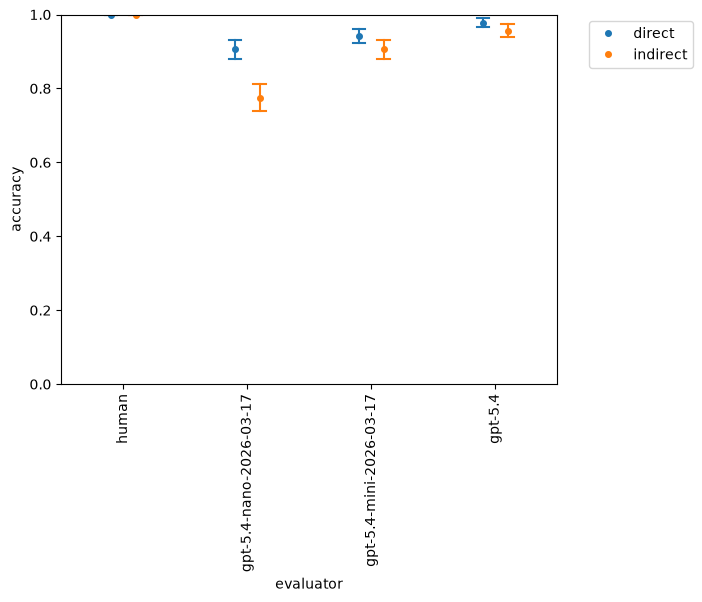

In [ ]:
sns.pointplot(
    data=df_long,
    x="evaluator",
    y="accuracy",
    hue="CONDITION",
    markersize=3,
    dodge=0.2,
    errorbar='se',
    linestyle="none",
    capsize=0.1,
    err_kws={"linewidth": 1.5}
)
plt.ylim([0, 1])
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


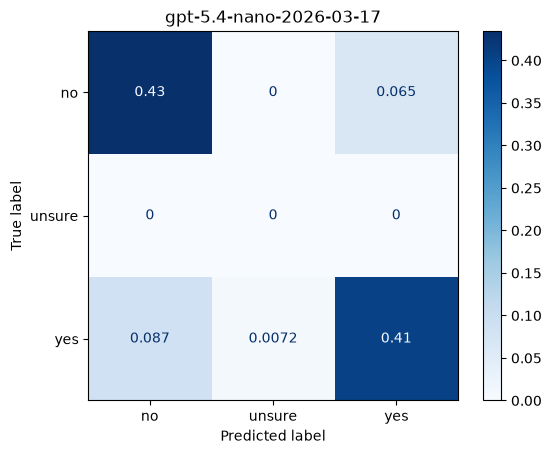

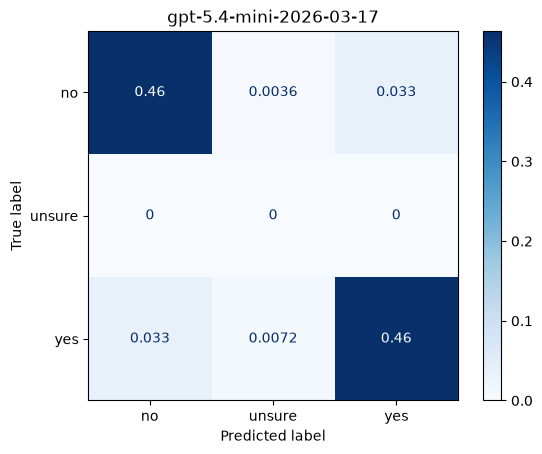

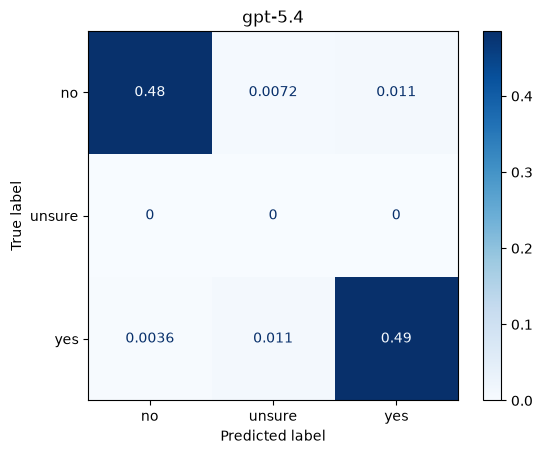

In [94]:
conf_matrix(df_long, MODELS)

#### ROC curve

<class 'float'>
<class 'float'>
<class 'float'>


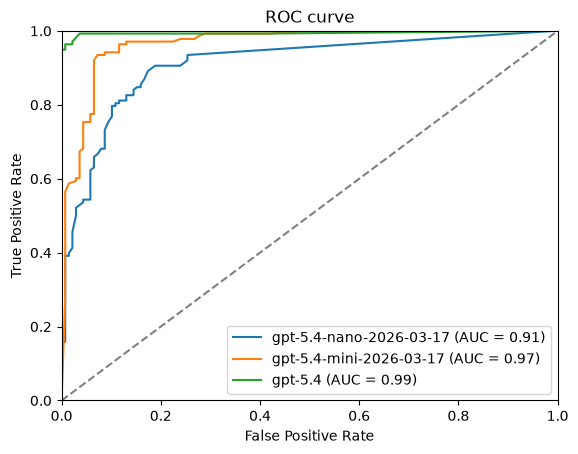

In [139]:
roc(df_long, MODELS)